<a href="https://colab.research.google.com/github/sba25046/ml-test/blob/main/machine_failure_random_forest_code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Random Forest Classification for the Machine Failure Dataset

Using Random Forest to predict machine failure (binary classification)

Data description: Machine_Failure.csv contains 10,000 rows, 14 columns.

Target: `Machine failure` (0 = no failure, 1 = failure)

# Import the libraries

In [145]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Import the CSV data

*  Note for Sam: I used the 'Files' section of colab to first upload the dataset to Colab. If you are testing this code please upload the file and ensure it matches the name Ive used in the code.



In [146]:
df = pd.read_csv('/Machine_Failure.csv')
print(df.shape)
df.head()

(10000, 14)


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


# Explore the dataset

In [147]:
# Check for nulls
print(df.isnull().sum())

UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64


In [148]:
# Check class balance
print(df['Machine failure'].value_counts())
print(df['Machine failure'].value_counts(normalize=True).round(3))

Machine failure
0    9661
1     339
Name: count, dtype: int64
Machine failure
0    0.966
1    0.034
Name: proportion, dtype: float64


In [149]:
# Count each individual failure type
failure_types = ['TWF', 'HDF', 'PWF', 'OSF', 'RNF']
print("Individual failure type counts:")
print(df[failure_types].sum())
print()


Individual failure type counts:
TWF     46
HDF    115
PWF     95
OSF     98
RNF     19
dtype: int64



In [150]:
# Check for rows where failure type columns don't match the Machine failure flag
failure_types = ['TWF', 'HDF', 'PWF', 'OSF', 'RNF']
any_failure_type = df[failure_types].sum(axis=1) > 0
mismatch = df[any_failure_type != df['Machine failure']]
print(f"Rows with inconsistency between failure flag and type columns: {len(mismatch)}")


Rows with inconsistency between failure flag and type columns: 27


Analysis: The dataset is heavily imbalanced- 96.6% of rows are no failure (represented by a 0), and only 3.4% are failure (represented by a 1). Some of the failure types are quite rare e.g. RNF- meaning theres an even lower sample size to work with for predicting individual failure types.

This means accuracy alone is misleading. A model that predicts 'no failure' for every row would score 96.6% accuracy while being useless in real life. We need to use precision, recall, and F1-score to properly evaluate performance of the model.

There are also 27 rows where the individual failure type columns (TWF, HDF, etc.) don't fully match the Machine failure flag. The volume is small enough that I will leave them in as they won't materially affect the model, but are worth noting.

I am going to focus on using random forest for binary classification, just predicting whether the machine fails or not. I will not focus on predicting what type of failure- this would be more advanced but it is possible with multi-class methods.

# Clean dataset

In [151]:
# Drop columns not needed: identifiers and individual failure type breakdowns
df = df.drop(columns=['UDI', 'Product ID', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF'])

# Encode the 'Type' column (L/M/H) using one-hot encoding so the model only receives numerical data
df = pd.get_dummies(df, columns=['Type'], drop_first=False)

df.head()

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,Type_H,Type_L,Type_M
0,298.1,308.6,1551,42.8,0,0,False,False,True
1,298.2,308.7,1408,46.3,3,0,False,True,False
2,298.1,308.5,1498,49.4,5,0,False,True,False
3,298.2,308.6,1433,39.5,7,0,False,True,False
4,298.2,308.7,1408,40.0,9,0,False,True,False


# Define features and target. Create the train and test split.

In [152]:
X = df.drop(columns=['Machine failure'])
y = df['Machine failure']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set size: {X_train.shape}")
print(f"Test set size: {X_test.shape}")

Training set size: (8000, 8)
Test set size: (2000, 8)


# Create and Train Model

In [153]:
# Basic Random Forest, set the state to 42 for replicability
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

# Check model performance

In [154]:
y_pred = rf_model.predict(X_test)

print(classification_report(y_test, y_pred, target_names=['No Failure', 'Failure']))

              precision    recall  f1-score   support

  No Failure       0.99      1.00      0.99      1939
     Failure       0.85      0.57      0.69        61

    accuracy                           0.98      2000
   macro avg       0.92      0.79      0.84      2000
weighted avg       0.98      0.98      0.98      2000



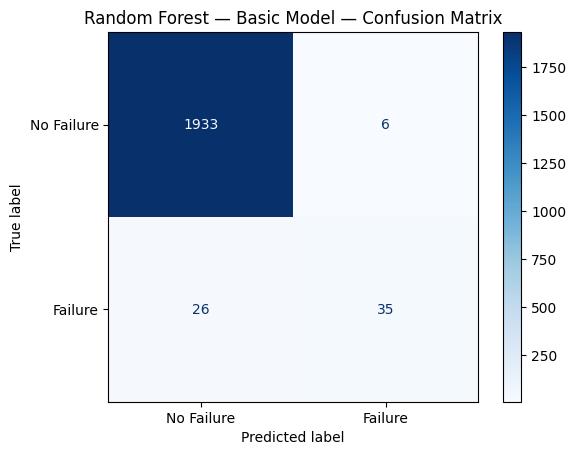

In [155]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Failure', 'Failure'])
disp.plot(cmap='Blues')
plt.title('Random Forest — Basic Model — Confusion Matrix')
plt.show()

Reflection: this model has high overall accuracy but the recall for the 'Failure' class is low which in a real life setting could be very dangerous or costly since it is missing many actual failures. This is a class imbalance problem.


# Add class balancing

In [156]:
rf_balanced = RandomForestClassifier(class_weight='balanced', random_state=42)
rf_balanced.fit(X_train, y_train)

y_pred_bal = rf_balanced.predict(X_test)

print(classification_report(y_test, y_pred_bal, target_names=['No Failure', 'Failure']))

              precision    recall  f1-score   support

  No Failure       0.98      1.00      0.99      1939
     Failure       0.89      0.39      0.55        61

    accuracy                           0.98      2000
   macro avg       0.94      0.70      0.77      2000
weighted avg       0.98      0.98      0.98      2000



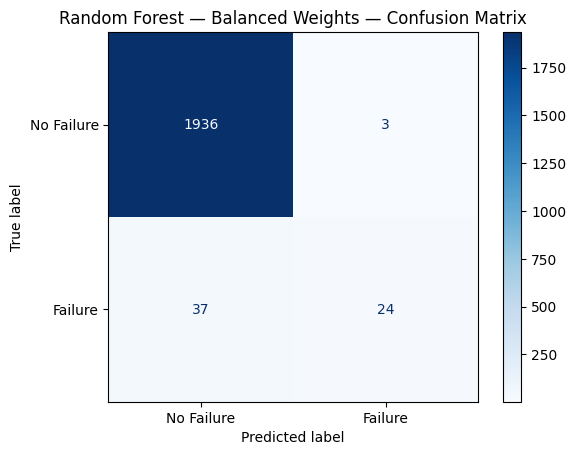

In [157]:
cm_bal = confusion_matrix(y_test, y_pred_bal)
disp_bal = ConfusionMatrixDisplay(confusion_matrix=cm_bal, display_labels=['No Failure', 'Failure'])
disp_bal.plot(cmap='Blues')
plt.title('Random Forest — Balanced Weights — Confusion Matrix')
plt.show()

reflection: Adding the class balancing did NOT change the model as I expected! the recall was actually worse and so was the overall F1. This means more real failures would be missed because of over correction.

# remove class balancing, add more trees

In [158]:
rf_tuned = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)
rf_tuned.fit(X_train, y_train)

y_pred_tuned = rf_tuned.predict(X_test)

print(classification_report(y_test, y_pred_tuned, target_names=['No Failure', 'Failure']))

              precision    recall  f1-score   support

  No Failure       0.99      1.00      0.99      1939
     Failure       0.89      0.56      0.69        61

    accuracy                           0.98      2000
   macro avg       0.94      0.78      0.84      2000
weighted avg       0.98      0.98      0.98      2000



reflection: doubling number of trees from default didnt change the F1. This is expected based on my understanding of random forest from class.. that beyond a certain number of trees adding more yields marginal gains.